In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import sys
import os
import math
import copy
import importlib

# 设置绘图风格
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. 数据加载与划分

In [75]:
# 加载 served 数据集
served_path = '../DataSplit/Served/served.csv'
df_served = pd.read_csv(served_path, parse_dates=['time'])

# 筛选目标受试者
TARGET_ID = 146
df_subject = df_served[df_served['id'] == TARGET_ID].copy().sort_values('time').reset_index(drop=True)

print(f"受试者 {TARGET_ID} 数据量: {len(df_subject)} 条")
print(f"时间范围: {df_subject['time'].min()} ~ {df_subject['time'].max()}")
print(f"Age: {df_subject['age'].iloc[0]}, BMI: {df_subject['bmi'].iloc[0]}")
df_subject.head()

受试者 146 数据量: 576 条
时间范围: 2012-01-01 00:00:00 ~ 2012-01-02 23:55:00
Age: 67.0, BMI: 25.8


,id,time,gl,age,bmi
0,146,2012-01-01 00:00:00,73.248693,67.0,25.8
1,146,2012-01-01 00:05:00,72.177965,67.0,25.8
2,146,2012-01-01 00:10:00,71.423547,67.0,25.8
3,146,2012-01-01 00:15:00,70.962566,67.0,25.8
4,146,2012-01-01 00:20:00,70.772143,67.0,25.8


In [76]:
# --- 数据划分配置 ---
# 方便调整微调集的比例
FINETUNE_RATIO = 0.3  # 微调集占比 (例如 0.5 表示前50%微调，后50%测试)

split_idx = int(len(df_subject) * FINETUNE_RATIO)

df_finetune = df_subject.iloc[:split_idx].copy()
df_test = df_subject.iloc[split_idx:].copy()

print(f"数据划分比例: {FINETUNE_RATIO*100}% 微调 / {(1-FINETUNE_RATIO)*100}% 测试")
print(f"微调集大小: {len(df_finetune)} 条")
print(f"测试集大小: {len(df_test)} 条")

# 检查数据是否充足
if len(df_finetune) < 50:
    print("⚠️ 警告: 微调集数据量过少，可能会影响效果")

数据划分比例: 30.0% 微调 / 70.0% 测试
微调集大小: 172 条
测试集大小: 404 条


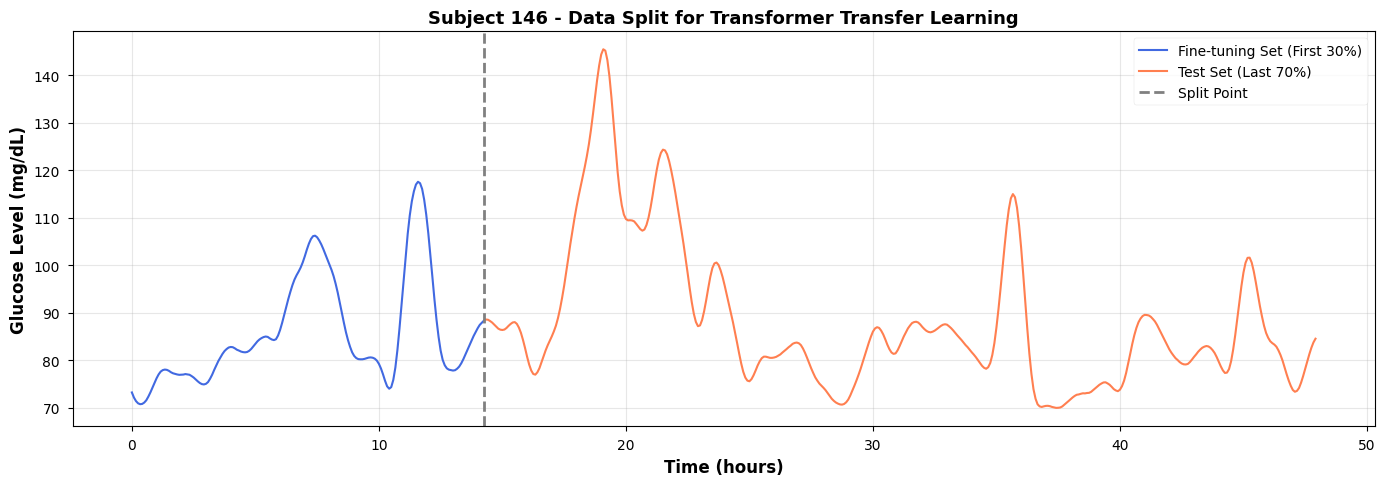

In [77]:
# 可视化数据划分
fig, ax = plt.subplots(figsize=(14, 5))

hours_finetune = np.arange(len(df_finetune)) * (5/60)
hours_test = np.arange(len(df_finetune), len(df_subject)) * (5/60)

ax.plot(hours_finetune, df_finetune['gl'].values, label=f'Fine-tuning Set (First {FINETUNE_RATIO*100:.0f}%)', color='royalblue', linewidth=1.5)
ax.plot(hours_test, df_test['gl'].values, label=f'Test Set (Last {(1-FINETUNE_RATIO)*100:.0f}%)', color='coral', linewidth=1.5)
ax.axvline(x=hours_finetune[-1], color='gray', linestyle='--', linewidth=2, label='Split Point')

ax.set_xlabel('Time (hours)', fontweight='bold')
ax.set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
ax.set_title(f'Subject {TARGET_ID} - Data Split for Transformer Transfer Learning', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. 模型定义与数据处理

In [78]:
# --- 模型超参数 (与预训练模型一致) ---
N_PAST = 12              # 历史窗口长度
PREDICTION_HORIZON = 6   # 预测步长
FEATURE_SIZE = 1         # 输入特征数 (血糖值)
D_MODEL = 64             # Transformer 嵌入维度
NHEAD = 4                # 多头注意力头数
NUM_LAYERS = 2           # Transformer 编码器层数
STATIC_LEN = 2           # 静态特征数 (Age, BMI)
DROPOUT = 0.1            # Dropout 率

print(f"模型参数: N_PAST={N_PAST}, HORIZON={PREDICTION_HORIZON}, D_MODEL={D_MODEL}, NHEAD={NHEAD}, NUM_LAYERS={NUM_LAYERS}")

模型参数: N_PAST=12, HORIZON=6, D_MODEL=64, NHEAD=4, NUM_LAYERS=2


In [79]:
# --- Transformer 模型定义 (与预训练模型结构完全一致) ---
# 代码直接复用于 transformer_prediction.ipynb 以确保兼容性

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (Batch, Seq_Len, d_model)
        return x + self.pe[:, :x.size(1), :]

class GlucoseTransformer(nn.Module):
    def __init__(self, feature_size=1, d_model=64, nhead=4, num_layers=2, static_len=2, dropout=0.1):
        super(GlucoseTransformer, self).__init__()
        
        # Input embedding: Project scalar glucose value to d_model
        self.input_embedding = nn.Linear(feature_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer Encoder
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        # Fusion & Output
        self.fc1 = nn.Linear(d_model + static_len, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)
        
    def forward(self, x_seq, x_static):
        # x_seq: (Batch, 1, Length) from Dataset
        # Need to permute to (Batch, Length, 1) for Linear projection
        x = x_seq.permute(0, 2, 1) # (Batch, Length, 1)
        
        # Embedding & Positional Encoding
        x = self.input_embedding(x) # (Batch, Length, d_model)
        x = self.pos_encoder(x)
        
        # Transformer Encoder
        x = self.transformer_encoder(x) # (Batch, Length, d_model)
        
        # Take the output of the last time step
        x = x[:, -1, :] # (Batch, d_model)
        
        # Concatenate with static features
        x = torch.cat((x, x_static), dim=1)
        
        # Fully Connected
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [80]:
# --- 数据集类定义 ---

class GlucoseDataset(Dataset):
    def __init__(self, X, y, n_past):
        # X shape: (N, n_past + 2)
        # 拆分为序列 (血糖) 和静态特征 (age, bmi)
        self.X_seq = torch.FloatTensor(X[:, :n_past]).unsqueeze(1)  # (N, 1, n_past)
        self.X_static = torch.FloatTensor(X[:, n_past:])            # (N, 2)
        self.y = torch.FloatTensor(y).unsqueeze(1)                  # (N, 1)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_static[idx], self.y[idx]

In [81]:
def create_dataset_single(data, n_past, prediction_horizon=1):
    """
    为单个受试者创建滑动窗口数据集
    返回: X (n_samples, n_features), y (n_samples,)
    """
    X, y = [], []
    
    gl_values = data['gl'].values
    age = data['age'].iloc[0]
    bmi = data['bmi'].iloc[0]
    
    if len(gl_values) < n_past + prediction_horizon:
        return np.array([]), np.array([])
    
    for i in range(n_past, len(gl_values) - prediction_horizon + 1):
        past_gl = gl_values[i-n_past:i]
        features = np.append(past_gl, [age, bmi])
        X.append(features)
        y.append(gl_values[i + prediction_horizon - 1])
    
    return np.array(X), np.array(y)

# 构建数据集
X_finetune, y_finetune = create_dataset_single(df_finetune, N_PAST, PREDICTION_HORIZON)
X_test, y_test = create_dataset_single(df_test, N_PAST, PREDICTION_HORIZON)

print(f"微调集样本数: {len(X_finetune)}")
print(f"测试集样本数: {len(X_test)}")

微调集样本数: 155
测试集样本数: 387


In [82]:
# --- 加载预训练时使用的 Scaler ---
# 为了保持一致性，使用 TrainTest 数据集重建 Scaler

train_path = '../DataSplit/TrainTest/Train.csv'
df_train_full = pd.read_csv(train_path, parse_dates=['time'])

def create_dataset_multi(data, n_past, prediction_horizon=1):
    """为多个受试者创建数据集"""
    X, y = [], []
    for subject_id, group in data.groupby('id'):
        group = group.sort_values('time')
        gl_values = group['gl'].values
        age = group['age'].iloc[0]
        bmi = group['bmi'].iloc[0]
        
        if len(gl_values) < n_past + prediction_horizon:
            continue
        
        for i in range(n_past, len(gl_values) - prediction_horizon + 1):
            past_gl = gl_values[i-n_past:i]
            features = np.append(past_gl, [age, bmi])
            X.append(features)
            y.append(gl_values[i + prediction_horizon - 1])
    
    return np.array(X), np.array(y)

X_train_full, _ = create_dataset_multi(df_train_full, N_PAST, PREDICTION_HORIZON)

# 重建 Scaler
scaler = StandardScaler()
scaler.fit(X_train_full)

# 标准化
X_finetune_scaled = scaler.transform(X_finetune)
X_test_scaled = scaler.transform(X_test)

# --- 构建完整数据集 (Full Set) 用于最终评估 ---
X_total_scaled = np.concatenate((X_finetune_scaled, X_test_scaled), axis=0)
y_total = np.concatenate((y_finetune, y_test), axis=0)

print("数据标准化完成 (使用预训练数据集的 Scaler)")
print(f"完整评估集 (Fine-tune + Test) 样本数: {len(y_total)}")

数据标准化完成 (使用预训练数据集的 Scaler)
完整评估集 (Fine-tune + Test) 样本数: 542


## 3. 加载预训练模型 & Baseline 评估

In [83]:
# --- 加载预训练模型 ---
pretrained_path = '../Prediction/Transformer/transformer_model.pth'

model_baseline = GlucoseTransformer(
    feature_size=FEATURE_SIZE, 
    d_model=D_MODEL, 
    nhead=NHEAD, 
    num_layers=NUM_LAYERS, 
    static_len=STATIC_LEN,
    dropout=DROPOUT
).to(device)

model_baseline.load_state_dict(torch.load(pretrained_path, map_location=device))
model_baseline.eval()

print("✅ 预训练 Transformer 模型加载成功!")
print(model_baseline)

✅ 预训练 Transformer 模型加载成功!
GlucoseTransformer(
  (input_embedding): Linear(in_features=1, out_features=64, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc1): Linear(in_features=66, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True

In [84]:
def calculate_metrics(y_true, y_pred):
    """计算评估指标"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    rmspe = np.sqrt(np.mean(np.square((y_true[mask] - y_pred[mask]) / y_true[mask]))) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'RMSPE': rmspe}

def predict(model, X_scaled, y, n_past, batch_size=64):
    """模型预测"""
    dataset = GlucoseDataset(X_scaled, y, n_past)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    model.eval()
    y_pred_list = []
    
    with torch.no_grad():
        for x_seq, x_static, _ in loader:
            x_seq, x_static = x_seq.to(device), x_static.to(device)
            outputs = model(x_seq, x_static)
            y_pred_list.extend(outputs.cpu().numpy())
    
    return np.array(y_pred_list).flatten()

In [85]:
# --- Baseline 评估: 在完整数据集上预测 ---
# 用户要求: 不仅在测试集，而是在 "微调集+测试集" 上评估

y_pred_baseline = predict(model_baseline, X_total_scaled, y_total, N_PAST)
metrics_baseline = calculate_metrics(y_total, y_pred_baseline)

print("=" * 60)
print(f"📊 Baseline 评估结果 (完整数据集: Fine-tune + Test)")
print("=" * 60)
for k, v in metrics_baseline.items():
    unit = 'mg/dL' if k in ['MAE', 'RMSE'] else '%'
    print(f"{k}: {v:.4f} {unit}")
print("=" * 60)

📊 Baseline 评估结果 (完整数据集: Fine-tune + Test)
MAE: 3.4287 mg/dL
RMSE: 4.4868 mg/dL
MAPE: 3.8606 %
RMSPE: 4.9989 %


## 4. 迁移学习 - 模型微调

In [86]:
# --- 创建并配置模型 (Freeze Encoder 策略) ---

model_finetuned = GlucoseTransformer(
    feature_size=FEATURE_SIZE, 
    d_model=D_MODEL, 
    nhead=NHEAD, 
    num_layers=NUM_LAYERS, 
    static_len=STATIC_LEN,
    dropout=DROPOUT
).to(device)

model_finetuned.load_state_dict(torch.load(pretrained_path, map_location=device))

# =========================================================
# 🎯 冻结编码器策略 (Freeze Encoder)
# =========================================================
# 策略:
# ❄️ 冻结 (Freeze): Input Embedding, Positional Encoding, Transformer Encoder
# 🔥 训练 (Train):  Fully Connected Layers (Head)
#
# 这种策略假设预训练模型已经学好了通用的血糖特征提取方式（Encoder部分），
# 我们只需要调整最后的回归层（Head）来适应特定受试者的输出分布。
# 它是最保守的策略，最不容易过拟合。

# 1. 首先冻结所有参数
for param in model_finetuned.parameters():
    param.requires_grad = False

# 2. 解冻全连接层 (Head)
# 根据模型定义: self.fc1, self.fc2
for param in model_finetuned.fc1.parameters():
    param.requires_grad = True

for param in model_finetuned.fc2.parameters():
    param.requires_grad = True

# 统计
total_params = sum(p.numel() for p in model_finetuned.parameters())
trainable_params = sum(p.numel() for p in model_finetuned.parameters() if p.requires_grad)

print("=" * 60)
print("🔧 Transformer 迁移学习配置 (Freeze Encoder 策略)")
print("=" * 60)
print(f"总参数量: {total_params:,}")
print(f"可训练参数: {trainable_params:,}")
print(f"可训练比例: {trainable_params/total_params*100:.2f}%")
print(f"状态: ❄️ Encoder Frozen, 🔥 Head Unfrozen")
print("-" * 60)

🔧 Transformer 迁移学习配置 (Freeze Encoder 策略)
总参数量: 71,425
可训练参数: 4,353
可训练比例: 6.09%
状态: ❄️ Encoder Frozen, 🔥 Head Unfrozen
------------------------------------------------------------


### 训练策略 (Freeze Encoder)

配置说明：
1. **优化器**: 使用 Adam 优化器。
2. **学习率**: 由于只训练最后的线性层，我们可以使用中等大小的学习率 (如 `1e-4`)，比全参数微调要大，因为线性层通常需要较大的梯度来快速适应。
3. **Dropout**: 继续使用 "Freeze-Dropout" (Eval Mode)，关闭 Dropout 以获得更稳定的梯度估计，特别是在冻结了 Encoder 的情况下。

In [87]:
# --- 冻结编码器微调训练 ---

# 恢复标准的 predict 函数
def predict(model, X_scaled, y, n_past, batch_size=64):
    dataset = GlucoseDataset(X_scaled, y, n_past)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()
    y_pred_list = []
    with torch.no_grad():
        for x_seq, x_static, _ in loader:
            x_seq, x_static = x_seq.to(device), x_static.to(device)
            outputs = model(x_seq, x_static)
            y_pred_list.extend(outputs.cpu().numpy())
    return np.array(y_pred_list).flatten()

# 超参数
# 只训练 Head，可以使用比全量微调稍大的 LR
FINETUNE_LR = 1e-4
FINETUNE_EPOCHS = 100     
BATCH_SIZE = 16          

# DataLoader
finetune_dataset = GlucoseDataset(X_finetune_scaled, y_finetune, N_PAST)
finetune_loader = DataLoader(finetune_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 优化器: 只优化 trainable parameters (Only Head)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_finetuned.parameters()), lr=FINETUNE_LR)
criterion = nn.MSELoss()
finetune_losses = []

print(f"开始 Freeze Encoder 微调 (Epochs={FINETUNE_EPOCHS}, LR={FINETUNE_LR})...")

for epoch in range(FINETUNE_EPOCHS):
    # 使用 eval() 模式:
    # 1. 禁用 Dropout (减少随机性，适合小样本)
    # 2. 如果有 BatchNorm，使用训练好的统计量
    # 注意: eval() 不会禁用梯度计算，只要 requires_grad=True 且不使用 torch.no_grad()，依然可以反向传播
    model_finetuned.eval() 
    
    running_loss = 0.0
    
    for x_seq, x_static, y in finetune_loader:
        x_seq, x_static, y = x_seq.to(device), x_static.to(device), y.to(device)
        
        optimizer.zero_grad()
        outputs = model_finetuned(x_seq, x_static)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(finetune_loader)
    finetune_losses.append(epoch_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{FINETUNE_EPOCHS}] Loss: {epoch_loss:.4f}")

print("-" * 50)
print("✅ Freeze Encoder 微调完成!")

开始 Freeze Encoder 微调 (Epochs=100, LR=0.0001)...
Epoch [10/100] Loss: 16.1009
Epoch [20/100] Loss: 15.3789
Epoch [30/100] Loss: 15.0129
Epoch [40/100] Loss: 14.3987
Epoch [50/100] Loss: 13.6787
Epoch [60/100] Loss: 13.5215
Epoch [70/100] Loss: 12.9712
Epoch [80/100] Loss: 12.2017
Epoch [90/100] Loss: 12.2528
Epoch [100/100] Loss: 12.1660
--------------------------------------------------
✅ Freeze Encoder 微调完成!


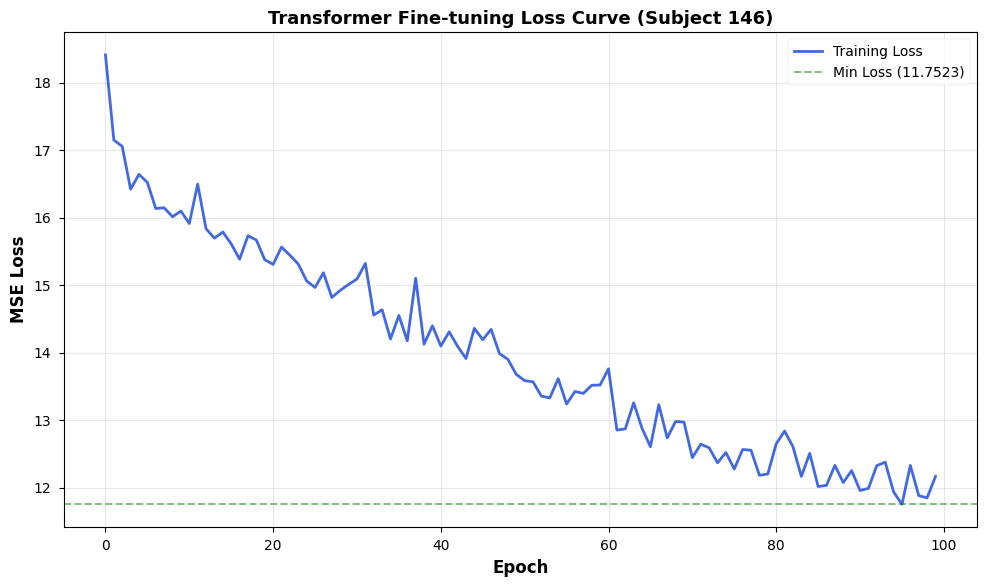

In [88]:
# --- 绘制微调训练过程 ---
# 注意：由于使用了全量数据微调(无验证集)，此处仅展示 Training Loss

plt.figure(figsize=(10, 6))
plt.plot(finetune_losses, label='Training Loss', color='royalblue', linewidth=2)
plt.axhline(y=min(finetune_losses), color='green', linestyle='--', alpha=0.5, label=f'Min Loss ({min(finetune_losses):.4f})')

plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('MSE Loss', fontweight='bold')
plt.title(f'Transformer Fine-tuning Loss Curve (Subject {TARGET_ID})', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [89]:
# --- 保存微调后的模型 ---
os.makedirs('models', exist_ok=True)
finetuned_model_path = f'models/transformer_subject_{TARGET_ID}_finetuned.pth'
torch.save(model_finetuned.state_dict(), finetuned_model_path)
print(f"✅ 微调模型已保存至: {os.path.abspath(finetuned_model_path)}")

✅ 微调模型已保存至: c:\Users\江一骏\Desktop\学习\HKU\dissertation\engineering\code\GlucosePrediction\src\Transfer\models\transformer_subject_146_finetuned.pth


## 5. Fine-tuned 模型评估

In [90]:
# --- Fine-tuned 评估 (完整数据集) ---
y_pred_finetuned = predict(model_finetuned, X_total_scaled, y_total, N_PAST)
metrics_finetuned = calculate_metrics(y_total, y_pred_finetuned)

print("=" * 60)
print(f"📊 Fine-tuned 评估结果 (Freeze Encoder, 完整数据集)")
print("=" * 60)
for k, v in metrics_finetuned.items():
    unit = 'mg/dL' if k in ['MAE', 'RMSE'] else '%'
    print(f"{k}: {v:.4f} {unit}")
print("=" * 60)

📊 Fine-tuned 评估结果 (Freeze Encoder, 完整数据集)
MAE: 2.7059 mg/dL
RMSE: 3.7665 mg/dL
MAPE: 2.9850 %
RMSPE: 3.9845 %


# --- 性能对比汇总表 ---
print("\n" + "=" * 70)
print(f"📈 Transformer 性能对比汇总 - Subject {TARGET_ID} (Full Set: Fine-tune + Test)")
print("=" * 70)
print(f"{'Metric':<10} {'Baseline':>15} {'Fine-tuned':>15} {'Improvement':>15}")
print("-" * 70)

for metric in ['MAE', 'RMSE', 'MAPE', 'RMSPE']:
    baseline_val = metrics_baseline[metric]
    finetuned_val = metrics_finetuned[metric]
    improvement = ((baseline_val - finetuned_val) / baseline_val) * 100
    
    unit = 'mg/dL' if metric in ['MAE', 'RMSE'] else '%'
    print(f"{metric:<10} {baseline_val:>12.4f} {unit} {finetuned_val:>12.4f} {unit} {improvement:>+12.2f}%")

print("=" * 70)

In [91]:
# --- 性能对比汇总表 ---
print("\n" + "=" * 70)
print(f"📈 Transformer 性能对比汇总 - Subject {TARGET_ID} (Horizon={PREDICTION_HORIZON*5}min)")
print("=" * 70)
print(f"{'Metric':<10} {'Baseline':>15} {'Fine-tuned':>15} {'Improvement':>15}")
print("-" * 70)

for metric in ['MAE', 'RMSE', 'MAPE', 'RMSPE']:
    baseline_val = metrics_baseline[metric]
    finetuned_val = metrics_finetuned[metric]
    improvement = ((baseline_val - finetuned_val) / baseline_val) * 100
    
    unit = 'mg/dL' if metric in ['MAE', 'RMSE'] else '%'
    print(f"{metric:<10} {baseline_val:>12.4f} {unit} {finetuned_val:>12.4f} {unit} {improvement:>+12.2f}%")

print("=" * 70)


📈 Transformer 性能对比汇总 - Subject 146 (Horizon=30min)
Metric            Baseline      Fine-tuned     Improvement
----------------------------------------------------------------------
MAE              3.4287 mg/dL       2.7059 mg/dL       +21.08%
RMSE             4.4868 mg/dL       3.7665 mg/dL       +16.05%
MAPE             3.8606 %       2.9850 %       +22.68%
RMSPE            4.9989 %       3.9845 %       +20.29%


C:\Users\江一骏\AppData\Local\Temp\ipykernel_21828\644676018.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


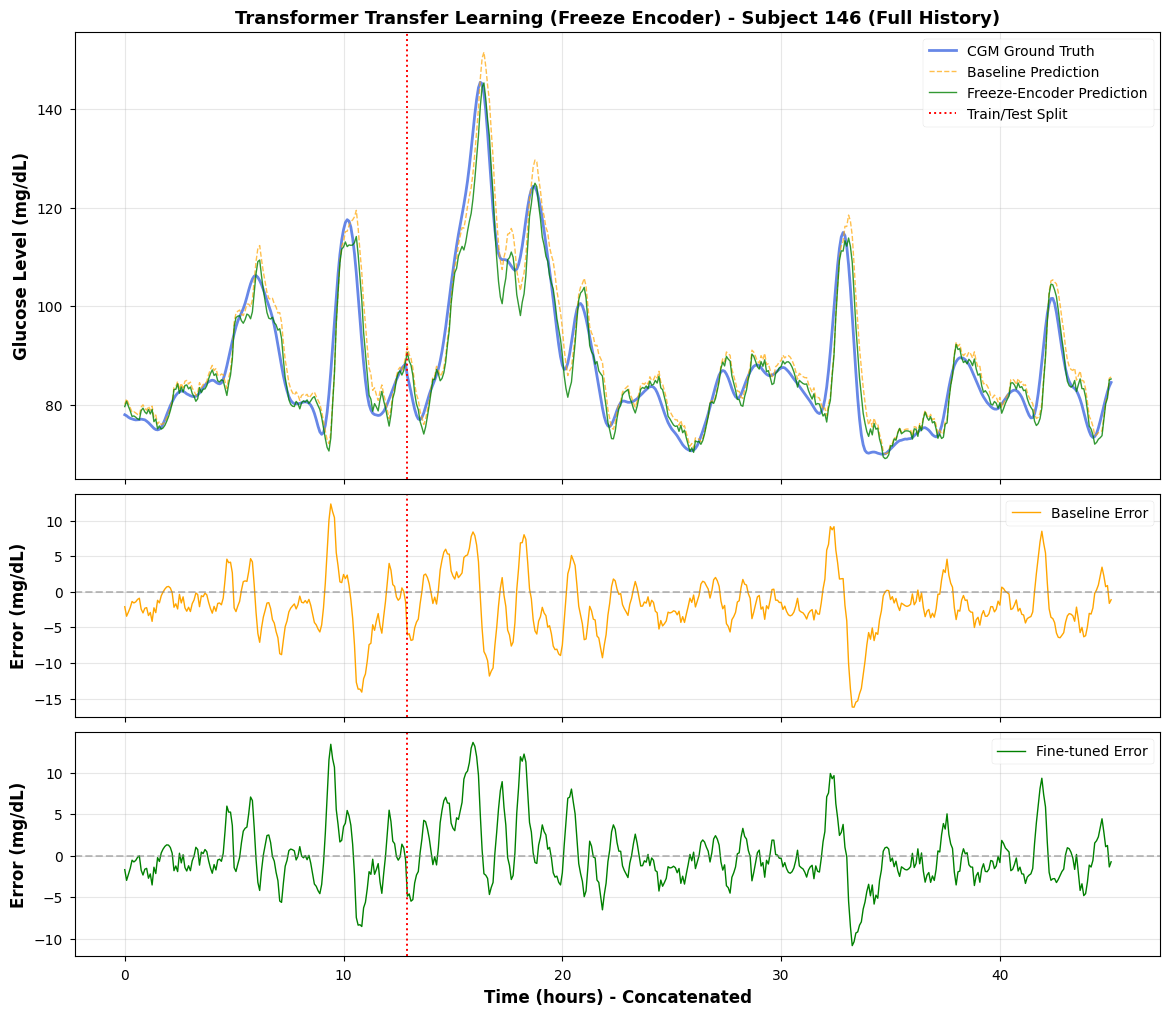

In [92]:
# --- 时序预测对比图 (完整展示) ---
# 时间轴需要重新构建以覆盖整个数据集 (忽略中间可能丢失的少许窗口，直接对齐 y_total)

# 为可视化简单起见，我们直接绘制 y_total 和 y_pred
# 生成对应的 dummy 时间索引 (每个点间隔 5 分钟)
time_axis = np.arange(len(y_total)) * (5/60)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True, 
                          gridspec_kw={'height_ratios': [2, 1, 1], 'hspace': 0.05})

# 上图: 血糖曲线与预测
ax1 = axes[0]
ax1.plot(time_axis, y_total, 
         label='CGM Ground Truth', color='royalblue', linewidth=2, alpha=0.8)
ax1.plot(time_axis, y_pred_baseline, label='Baseline Prediction', 
            color='orange', linewidth=1, alpha=0.7, linestyle='--')
ax1.plot(time_axis, y_pred_finetuned, label='Freeze-Encoder Prediction', 
            color='green', linewidth=1, alpha=0.8)

# 标记微调集和测试集的分界线 (近似)
split_point = len(y_finetune) * (5/60)
ax1.axvline(x=split_point, color='red', linestyle=':', label='Train/Test Split')

ax1.set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
ax1.set_title(f'Transformer Transfer Learning (Freeze Encoder) - Subject {TARGET_ID} (Full History)', fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# 中图: Baseline 误差
ax2 = axes[1]
error_baseline = y_total - y_pred_baseline
ax2.plot(time_axis, error_baseline, label='Baseline Error', color='orange', linewidth=1)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=split_point, color='red', linestyle=':')
ax2.set_ylabel('Error (mg/dL)', fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# 下图: Fine-tuned 误差
ax3 = axes[2]
error_finetuned = y_total - y_pred_finetuned
ax3.plot(time_axis, error_finetuned, label='Fine-tuned Error', color='green', linewidth=1)
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax3.axvline(x=split_point, color='red', linestyle=':')
ax3.set_ylabel('Error (mg/dL)', fontweight='bold')
ax3.set_xlabel('Time (hours) - Concatenated', fontweight='bold')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\江一骏\AppData\Local\Temp\ipykernel_21828\816037791.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([error_baseline, error_finetuned], labels=['Baseline', 'Fine-tuned'],


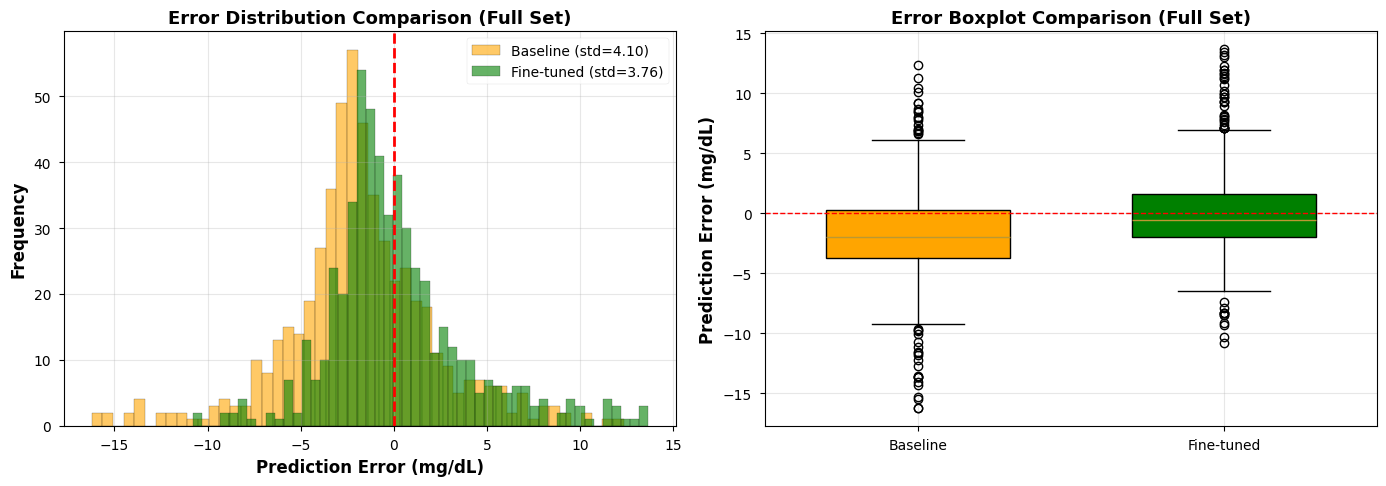

In [93]:
# --- 误差分布对比 (完整数据集) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 误差直方图
ax1 = axes[0]
ax1.hist(error_baseline, bins=50, alpha=0.6, label=f'Baseline (std={np.std(error_baseline):.2f})', color='orange', edgecolor='black')
ax1.hist(error_finetuned, bins=50, alpha=0.6, label=f'Fine-tuned (std={np.std(error_finetuned):.2f})', color='green', edgecolor='black')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Prediction Error (mg/dL)', fontweight='bold')
ax1.set_ylabel('Frequency', fontweight='bold')
ax1.set_title('Error Distribution Comparison (Full Set)', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 箱线图
ax2 = axes[1]
bp = ax2.boxplot([error_baseline, error_finetuned], labels=['Baseline', 'Fine-tuned'], 
                  patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('orange')
bp['boxes'][1].set_facecolor('green')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax2.set_ylabel('Prediction Error (mg/dL)', fontweight='bold')
ax2.set_title('Error Boxplot Comparison (Full Set)', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

📊 Clarke Error Grid 对比 (Full Set)


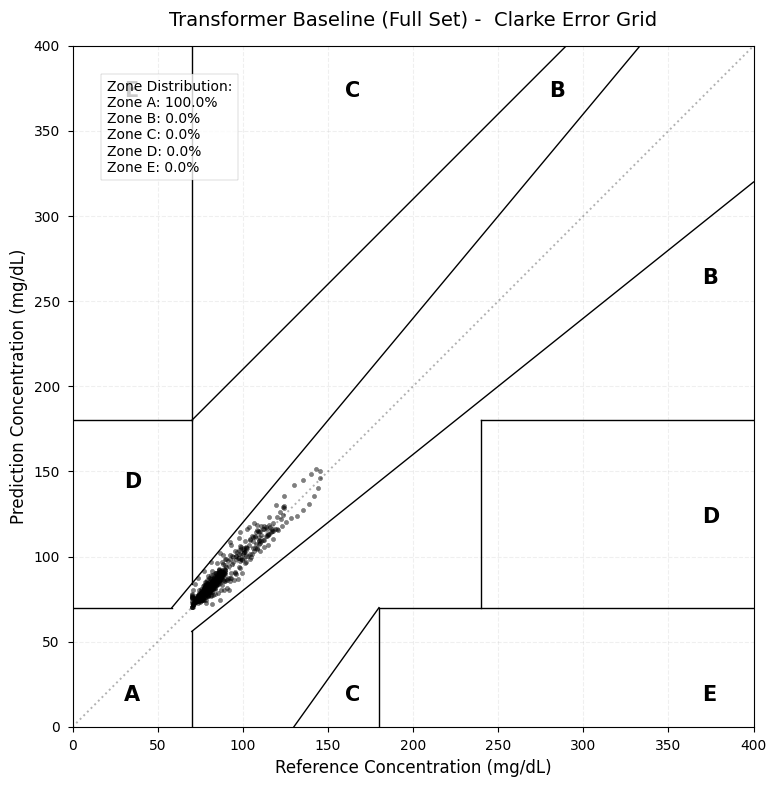

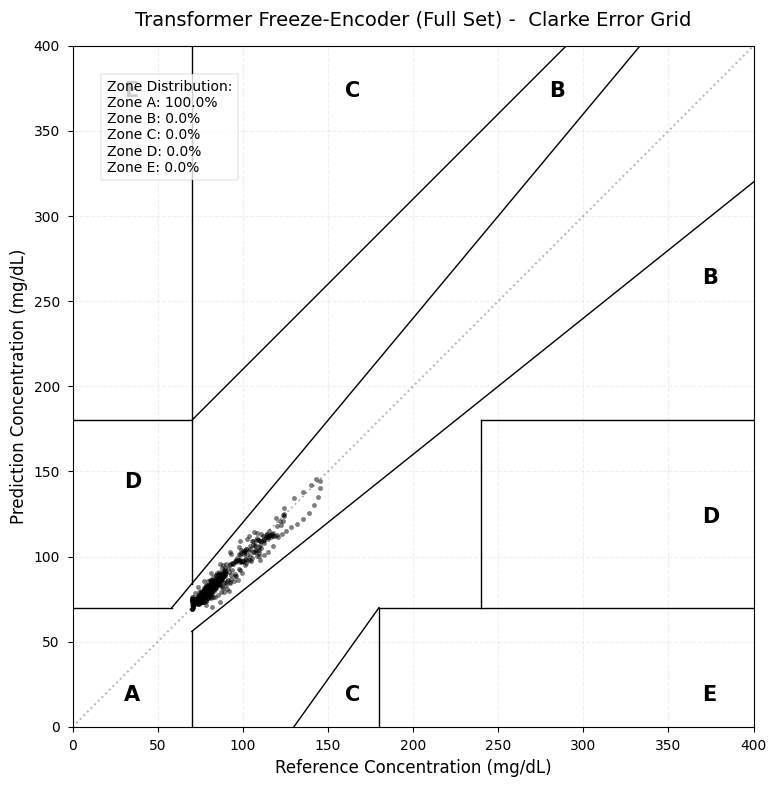

In [94]:
# --- Clarke Error Grid 对比 ---
utils_path = os.path.abspath('../../utils')
if utils_path not in sys.path:
    sys.path.append(utils_path)

import ceg_utils
importlib.reload(ceg_utils)

print("=" * 60)
print("📊 Clarke Error Grid 对比 (Full Set)")
print("=" * 60)

# Baseline CEG
plt_baseline, zones_baseline = ceg_utils.clarke_error_grid(
    y_total, y_pred_baseline, 
    title_string=f"Transformer Baseline (Full Set) - "
)
plt_baseline.show()

# Fine-tuned CEG
plt_finetuned, zones_finetuned = ceg_utils.clarke_error_grid(
    y_total, y_pred_finetuned,
    title_string=f"Transformer Freeze-Encoder (Full Set) - "
)
plt_finetuned.show()

In [95]:
# --- Clarke Error Grid 区域对比汇总 ---
zones = ['A', 'B', 'C', 'D', 'E']
zones_baseline_dict = {z: p for z, p in zip(zones, zones_baseline)}
zones_finetuned_dict = {z: p for z, p in zip(zones, zones_finetuned)}

print("\n" + "=" * 60)
print("📊 Transformer Clarke Error Grid 区域分布对比")
print("=" * 60)
print(f"{'Zone':<10} {'Baseline':>15} {'Fine-tuned':>15} {'Change':>15}")
print("-" * 60)

for zone in zones:
    b_val = zones_baseline_dict[zone]
    f_val = zones_finetuned_dict[zone]
    change = f_val - b_val
    print(f"{zone:<10} {b_val:>14.2f}% {f_val:>14.2f}% {change:>+14.2f}%")

print("-" * 60)
ab_baseline = zones_baseline_dict['A'] + zones_baseline_dict['B']
ab_finetuned = zones_finetuned_dict['A'] + zones_finetuned_dict['B']
print(f"{'A+B (Safe)':<10} {ab_baseline:>14.2f}% {ab_finetuned:>14.2f}% {ab_finetuned-ab_baseline:>+14.2f}%")
print("=" * 60)


📊 Transformer Clarke Error Grid 区域分布对比
Zone              Baseline      Fine-tuned          Change
------------------------------------------------------------
A                  100.00%         100.00%          +0.00%
B                    0.00%           0.00%          +0.00%
C                    0.00%           0.00%          +0.00%
D                    0.00%           0.00%          +0.00%
E                    0.00%           0.00%          +0.00%
------------------------------------------------------------
A+B (Safe)         100.00%         100.00%          +0.00%


## 7. 学习曲线分析 (Learning Curve Analysis)

我们将探究迁移学习在小样本上的**少样本学习能力 (Few-shot Learning Capability)**。


In [96]:
# --- 学习曲线实验配置 ---

# 1. 划分固定测试集 (Fixed Test Set)
# 假设每个受试者最后 30% 为固定测试集，前 70% 为潜在微调数据池
FIXED_TEST_RATIO = 0.3
split_point_exp = int(len(df_subject) * (1 - FIXED_TEST_RATIO))

df_pool = df_subject.iloc[:split_point_exp].copy()       # 微调数据池 (Training Pool)
df_test_exp = df_subject.iloc[split_point_exp:].copy()   # 固定测试集 (Fixed Test Set)

# 构建数据集
# 注意: 需要使用 create_dataset_single 函数
X_test_exp, y_test_exp = create_dataset_single(df_test_exp, N_PAST, PREDICTION_HORIZON)
# 使用之前的 scaler 进行标准化
X_test_exp_scaled = scaler.transform(X_test_exp)

print("=" * 60)
print(f"🔬 学习曲线实验设置")
print("=" * 60)
print(f"数据池 (Pool) 大小    : {len(df_pool)} 条 (前 {(1-FIXED_TEST_RATIO)*100:.0f}%)")
print(f"固定测试集 (Test) 大小: {len(df_test_exp)} 条 (后 {FIXED_TEST_RATIO*100:.0f}%)")

# 计算 Baseline 在此固定测试集上的性能 (作为参考基准)
y_pred_base_exp = predict(model_baseline, X_test_exp_scaled, y_test_exp, N_PAST)
metrics_base_exp = calculate_metrics(y_test_exp, y_pred_base_exp)
print(f"Baseline (样本=0) MAE : {metrics_base_exp['MAE']:.4f} mg/dL")
print("-" * 60)

# 2. 实验循环
ratios = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0] # 使用数据池的比例
experiment_results = []

print(f"开始实验: 测试数据比例 {ratios} ...")

for r in ratios:
    # 截取对应比例的微调数据
    sub_split = int(len(df_pool) * r)
    df_current_ft = df_pool.iloc[:sub_split].copy()
    
    # 构建微调数据集
    X_ft, y_ft = create_dataset_single(df_current_ft, N_PAST, PREDICTION_HORIZON)
    
    # 样本检查
    if len(X_ft) < BATCH_SIZE:
        print(f"  > [Skip] Ratio {r:.1f}: 样本不足 ({len(X_ft)})")
        continue

    X_ft_scaled = scaler.transform(X_ft)
    ft_ds = GlucoseDataset(X_ft_scaled, y_ft, N_PAST)
    ft_ldr = DataLoader(ft_ds, batch_size=BATCH_SIZE, shuffle=True)
    
    # --- 重新初始化模型 (Reset) ---
    model_exp = GlucoseTransformer(
        feature_size=FEATURE_SIZE, d_model=D_MODEL, nhead=NHEAD, 
        num_layers=NUM_LAYERS, static_len=STATIC_LEN, dropout=DROPOUT
    ).to(device)
    model_exp.load_state_dict(torch.load(pretrained_path, map_location=device))
    
    # --- 策略: Frozen Encoder (保持一致) ---
    for param in model_exp.parameters(): param.requires_grad = False    # Freeze All
    for param in model_exp.fc1.parameters(): param.requires_grad = True # Unfreeze Head
    for param in model_exp.fc2.parameters(): param.requires_grad = True # Unfreeze Head
    
    # 训练 setup
    opt = optim.Adam(filter(lambda p: p.requires_grad, model_exp.parameters()), lr=FINETUNE_LR)
    crit = nn.MSELoss()
    
    # 快速微调 (固定 30 Epochs)
    model_exp.eval()
    for _ in range(30):
        for bx, bs, by in ft_ldr:
            bx, bs, by = bx.to(device), bs.to(device), by.to(device)
            opt.zero_grad()
            out = model_exp(bx, bs)
            loss = crit(out, by)
            loss.backward()
            opt.step()
            
    # 评估 (固定测试集)
    y_p = predict(model_exp, X_test_exp_scaled, y_test_exp, N_PAST)
    m = calculate_metrics(y_test_exp, y_p)
    
    # 记录
    res = {
        'ratio': r,
        'n_samples': len(X_ft),
        'MAE': m['MAE'],
        'RMSE': m['RMSE'],
        'MAPE': m['MAPE']
    }
    experiment_results.append(res)
    print(f"  > [Ratio {r:.1f}] Samples: {len(X_ft):<4} -> MAE: {m['MAE']:.4f}, RMSE: {m['RMSE']:.4f}")

print("✅ 实验完成")

🔬 学习曲线实验设置
数据池 (Pool) 大小    : 403 条 (前 70%)
固定测试集 (Test) 大小: 173 条 (后 30%)
Baseline (样本=0) MAE : 3.6896 mg/dL
------------------------------------------------------------
开始实验: 测试数据比例 [0.1, 0.2, 0.3, 0.5, 0.7, 1.0] ...
  > [Ratio 0.1] Samples: 23   -> MAE: 3.0065, RMSE: 4.4684
  > [Ratio 0.2] Samples: 63   -> MAE: 3.1964, RMSE: 4.5904
  > [Ratio 0.3] Samples: 103  -> MAE: 3.0029, RMSE: 4.3699
  > [Ratio 0.5] Samples: 184  -> MAE: 2.9244, RMSE: 4.1570
  > [Ratio 0.7] Samples: 265  -> MAE: 3.0653, RMSE: 4.1978
  > [Ratio 1.0] Samples: 386  -> MAE: 2.9572, RMSE: 4.1241
✅ 实验完成


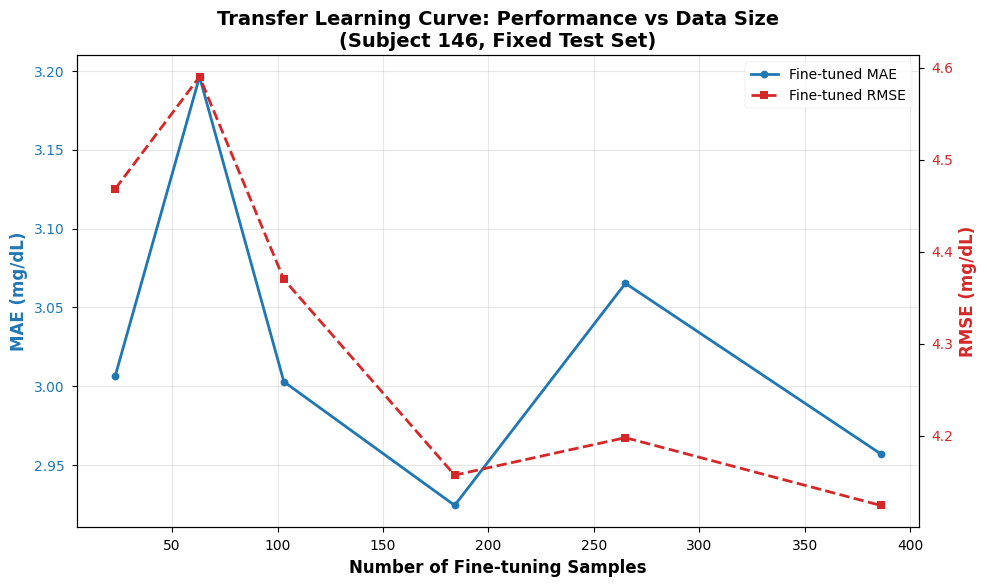

In [97]:
# --- 学习曲线可视化 ---
if len(experiment_results) > 0:
    exp_df = pd.DataFrame(experiment_results)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # 绘制 MAE
    color = 'tab:blue'
    ax1.set_xlabel('Number of Fine-tuning Samples', fontweight='bold', fontsize=12)
    ax1.set_ylabel('MAE (mg/dL)', color=color, fontweight='bold', fontsize=12)
    line1 = ax1.plot(exp_df['n_samples'], exp_df['MAE'], marker='o', color=color, linewidth=2, label='Fine-tuned MAE')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)

    # 绘制 RMSE
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('RMSE (mg/dL)', color=color, fontweight='bold', fontsize=12)
    line2 = ax2.plot(exp_df['n_samples'], exp_df['RMSE'], marker='s', color=color, linewidth=2, linestyle='--', label='Fine-tuned RMSE')
    ax2.tick_params(axis='y', labelcolor=color)


    # 合并图例
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')

    plt.title(f'Transfer Learning Curve: Performance vs Data Size\n(Subject {TARGET_ID}, Fixed Test Set)', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("没有收集到实验结果，可能是样本不足。")